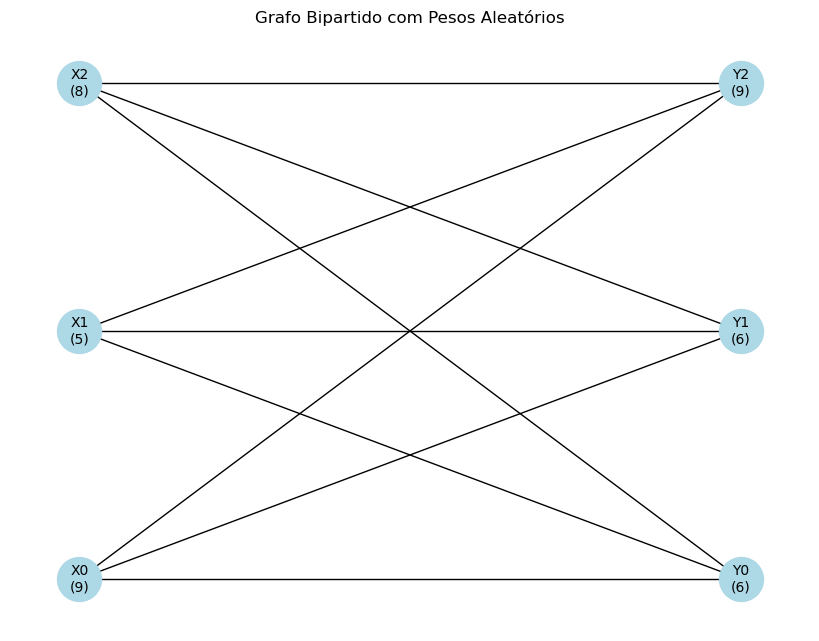

Iniciou às 2025-04-03 23:08:30.672

Com Programação Dinâmica:
Melhor caminho: ['X0', 'Y2', 'X2', 'Y0', 'Y1', 'X1']
Tempo de execução: 0.007001638412475586 segundos
Quantidade de estados  a serem gerados: 49
Número de entradas na tabela dinâmica: 49
Número de reusos: 78
Número de estados distintos usados:  42

Vértices escolhidos por Ana: ['X0', 'X2', 'Y1']
Ganho de Ana: 23

Vértices escolhidos por Bob: ['Y2', 'Y0', 'X1']
Ganho de Bob: 20

Estados Reutilizados:
('X2', 'Y2') → reutilizado 3 vezes
Caminho percorrido: [('X0', 'X1', 'Y1', 'Y0'), ('X0', 'Y0', 'Y1', 'X1'), ('X1', 'Y0', 'Y1', 'X0')]
  Momentos de reutilização:
 Historico:  ('X0', 'X1', 'Y1', 'Y0')
 Historico:  ('X0', 'Y0', 'Y1', 'X1')
 Historico:  ('X1', 'Y0', 'Y1', 'X0')
  Instantes de reutilização:
('X2', 'Y1') → reutilizado 3 vezes
Caminho percorrido: [('X0', 'X1', 'Y2', 'Y0'), ('X0', 'Y0', 'Y2', 'X1'), ('X1', 'Y0', 'Y2', 'X0')]
  Momentos de reutilização:
 Historico:  ('X0', 'X1', 'Y2', 'Y0')
 Historico:  ('X0', 'Y0', 'Y2'

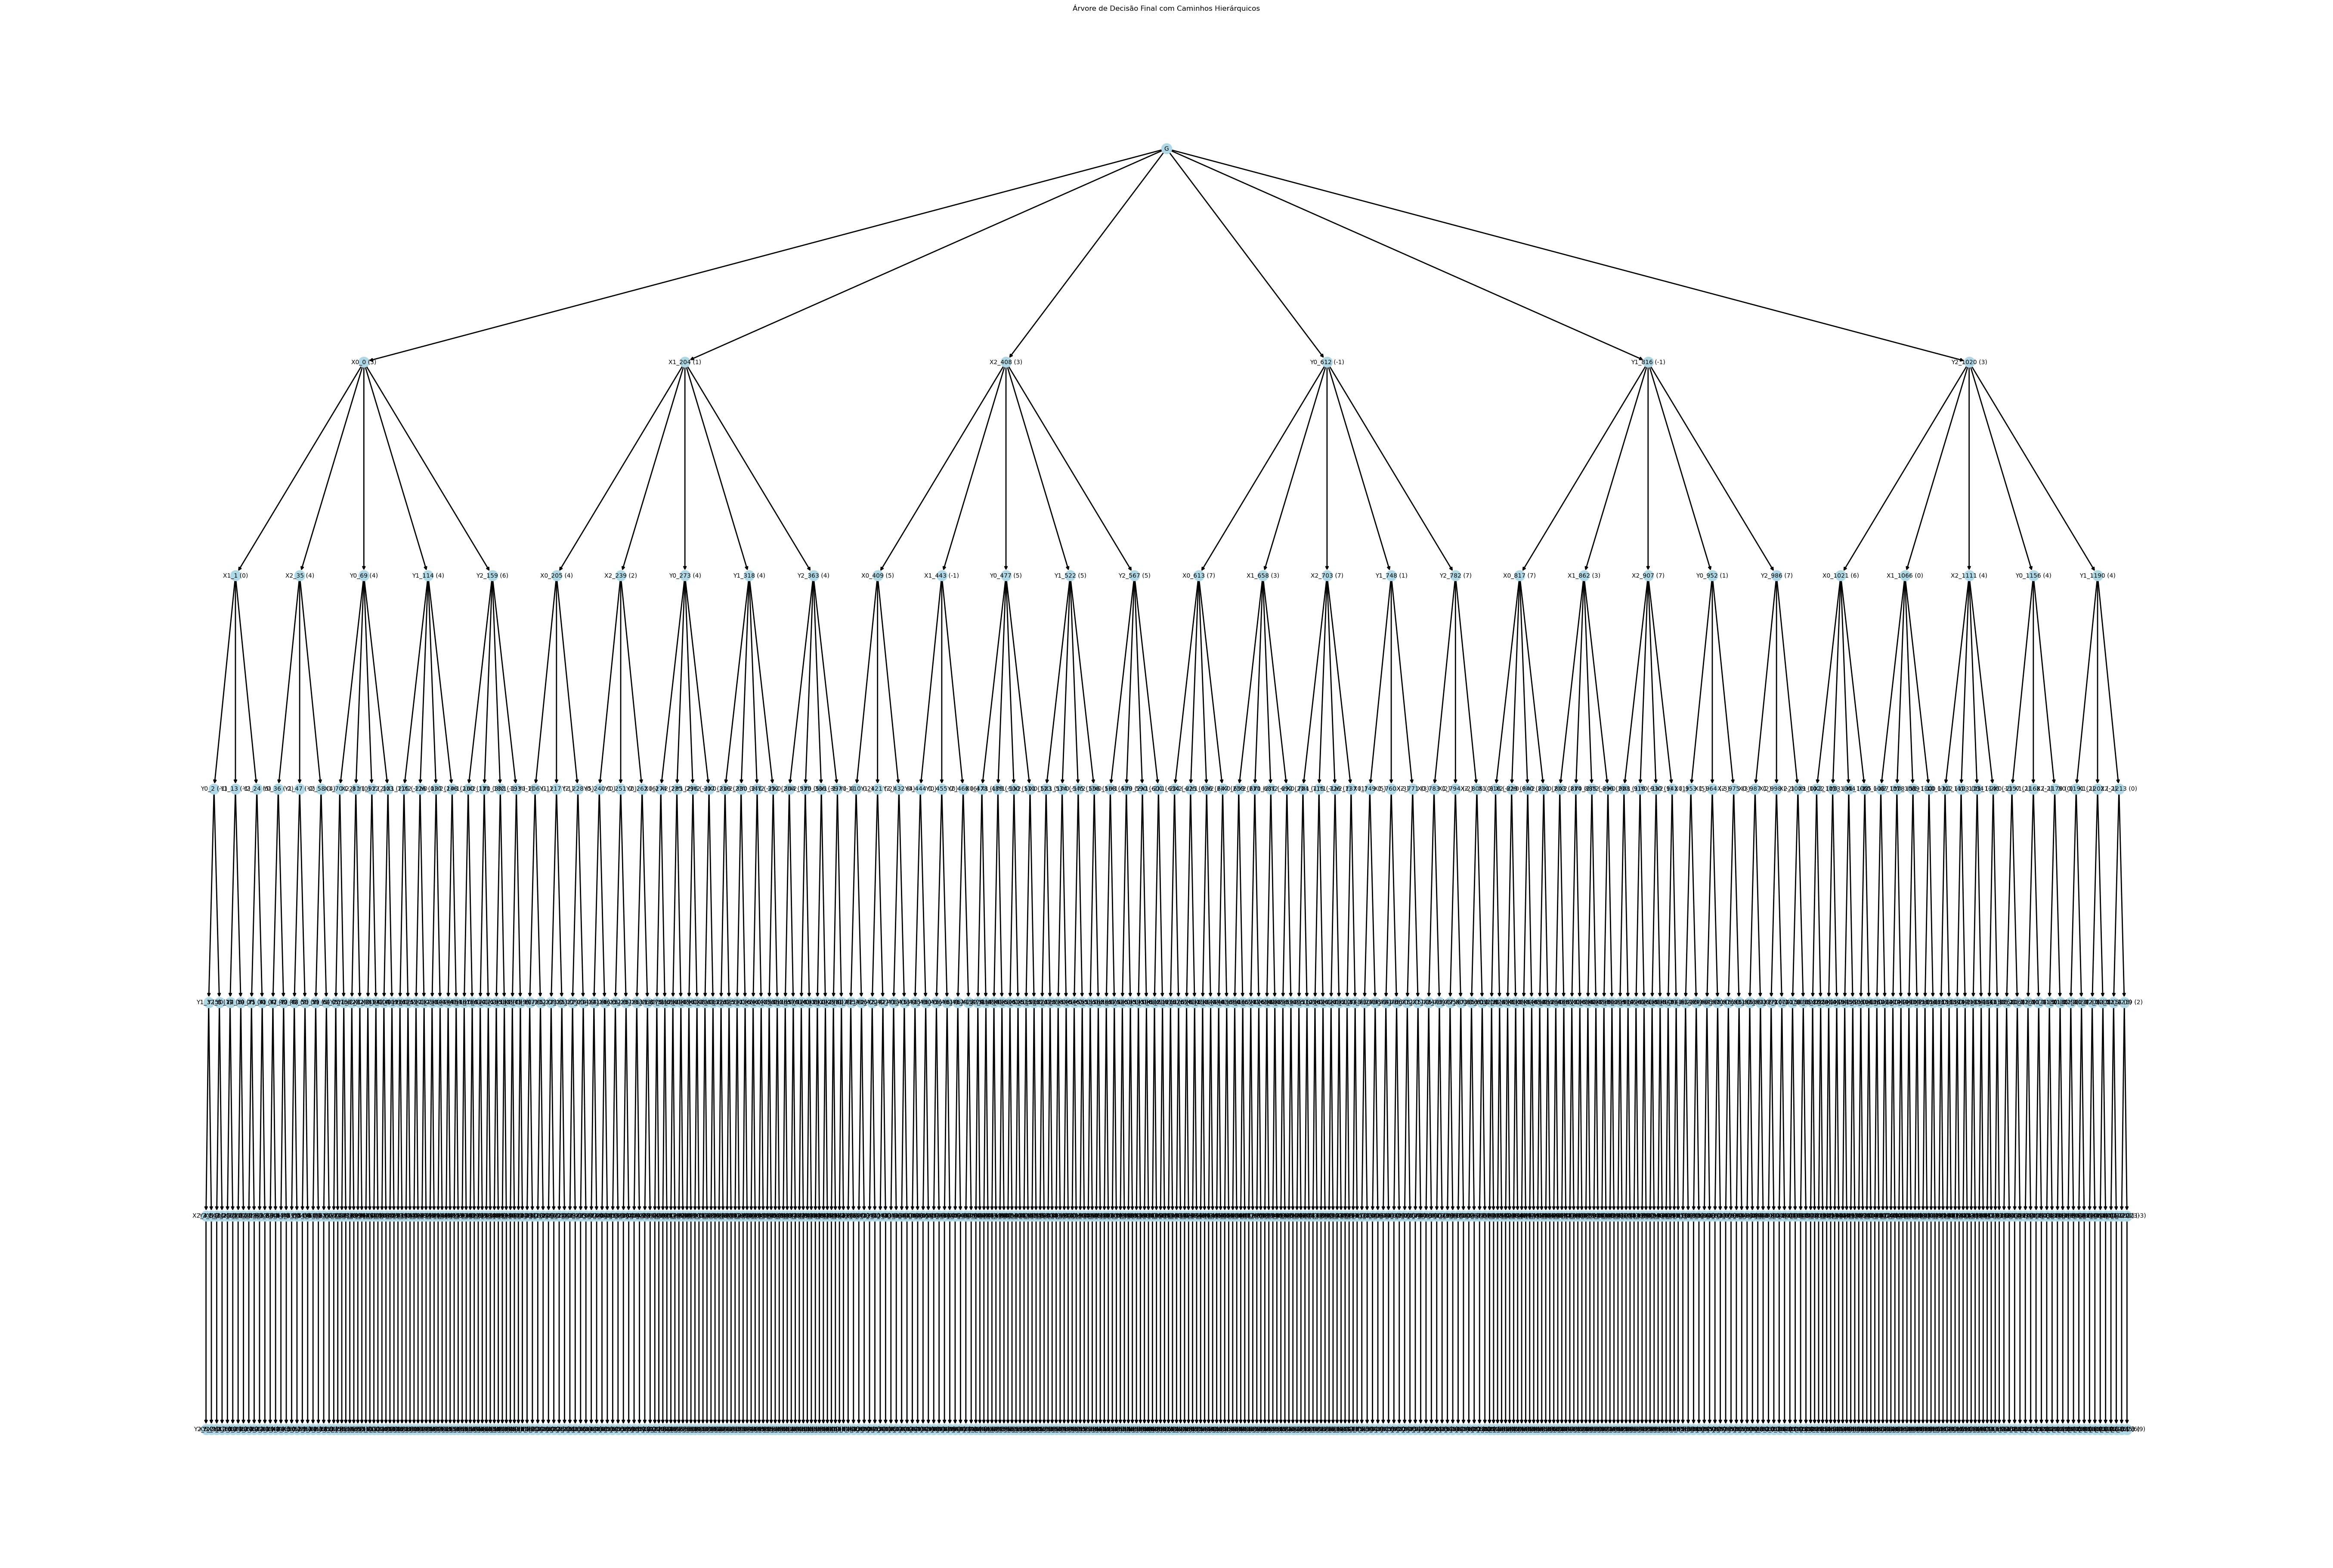

In [1]:
from geracao_grafos import *
from valG import *
from problemasPolinomiais.gulosoBicoloridoCiclo import *
from problemasPolinomiais.gulosoCompleto import *
from funcoesDP import *
from otimizacoesPD.caminho_otimizado_pd import *
import gc

def mainSemDp(grafo, pesos):
    
    inicio_tempo = time.time()
    melhor_valor, arvore_decisao, melhor_caminho = valor(grafo, pesos)
    fim_tempo = time.time()
    print("Sem Programação Dinâmica:")
    print("Melhor caminho:", melhor_caminho)
    print("Tempo de execução:", fim_tempo - inicio_tempo, "segundos")
    calcular_ganhos(melhor_caminho, pesos)
    imprimirArvoreDecisao(arvore_decisao,False)


def mainDP(grafo, pesos):
    inicio_tempo = time.time()
    memo = {}
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]  # Mantém milissegundos
  # Captura o instante de reutilização
    print(f"Iniciou às {timestamp}")
    melhor_valor_dp, arvore_decisao_dp, melhor_caminho_dp = valor_dp(grafo, pesos, memo)
    fim_tempo = time.time()
    print("\nCom Programação Dinâmica:")
    print("Melhor caminho:", melhor_caminho_dp)
    print("Tempo de execução:", fim_tempo - inicio_tempo, "segundos")
    quantidade_estados = contar_estados(grafo)
    print("Quantidade de estados  a serem gerados:", quantidade_estados)
    print("Número de entradas na tabela dinâmica:", len(memo))
    print("Número de reusos:", len(contagem_reuso_dp))
    print("Número de estados distintos usados: ",len(estados_reusados))
    calcular_ganhos(melhor_caminho_dp, pesos)
    imprime_estados_reusados()
    imprime_estados_nao_reutilizados(memo)
    #imprime_tabela_dp(memo)
    #imprimirArvoreDecisao(arvore_decisao_dp)



def main():
    gc.collect()  # Força a coleta de lixo
    m, n = 3,3
    altura = 4
    
    #grafo, pesos = gerar_grafo_ciclo(4)      # Gera um ciclo de 5 nós
    #grafo, pesos = gerar_grafo_completo(13)   # Gera um grafo completo de 6 nós
    #grafo, pesos = gerar_grafo_caminho(6)    # Gera um caminho de 4 nós
    #grafo, pesos, conjunto_x, conjunto_y = criar_grafo_bipartido(m, n)
    grafo, pesos, conjunto_x, conjunto_y = criar_grafo_bipartido_completo(m, n)
    #grafo, pesos = grafoSimples()
    #grafo, pesos = arvoreCompleta(altura)


    mainDP( grafo, pesos)
    print("==================================================================================================")
    print("==================================================================================================")

    #main_caminho_otimiziado_pd(grafo,pesos)

    mainSemDp( grafo, pesos)

    #mainBicoloracaoCaminho( grafo, pesos)
    #mainGulosoCompleto(grafo,pesos)
    #mainGulosoBicoloridoCiclo(grafo,pesos)

if __name__ == "__main__":
    main()